## Engagement Behavior EDA (Professional Version)
Goal: Evaluate how engagement signals relate to churn with consistent visual, statistical, and effect-size evidence.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import pandas as pd
from scipy import stats

df = pd.read_csv('../../../Data/processed/cleaned_customer_data.csv')

In [10]:
engagement_feature_names = [
    "Login_Frequency",
    "Pages_Per_Session",
    "Session_Duration_Avg",
    "Mobile_App_Usage",
    "Social_Media_Engagement_Score",
]

engagement_data = df[engagement_feature_names].copy()

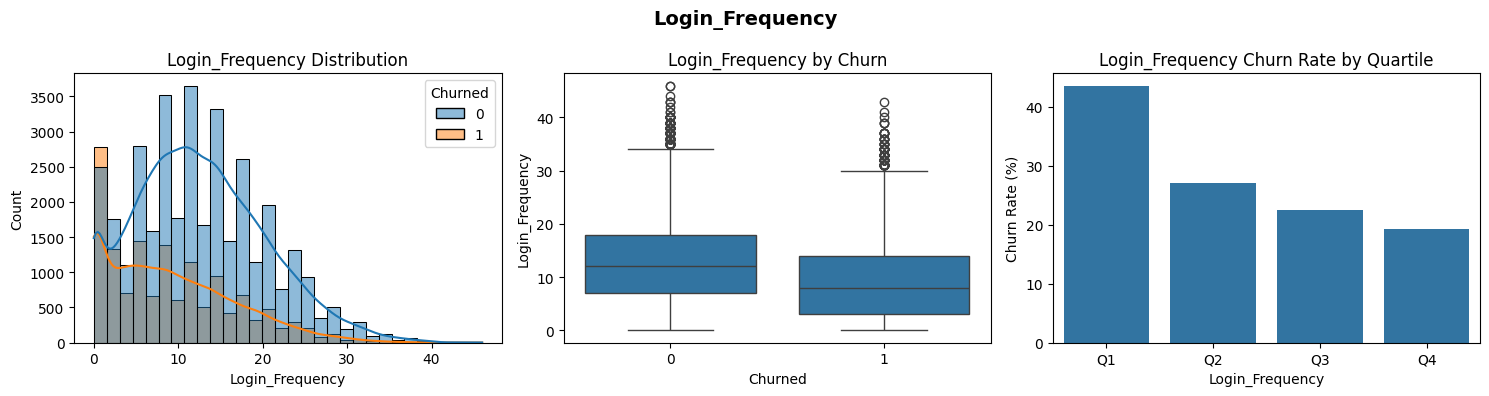

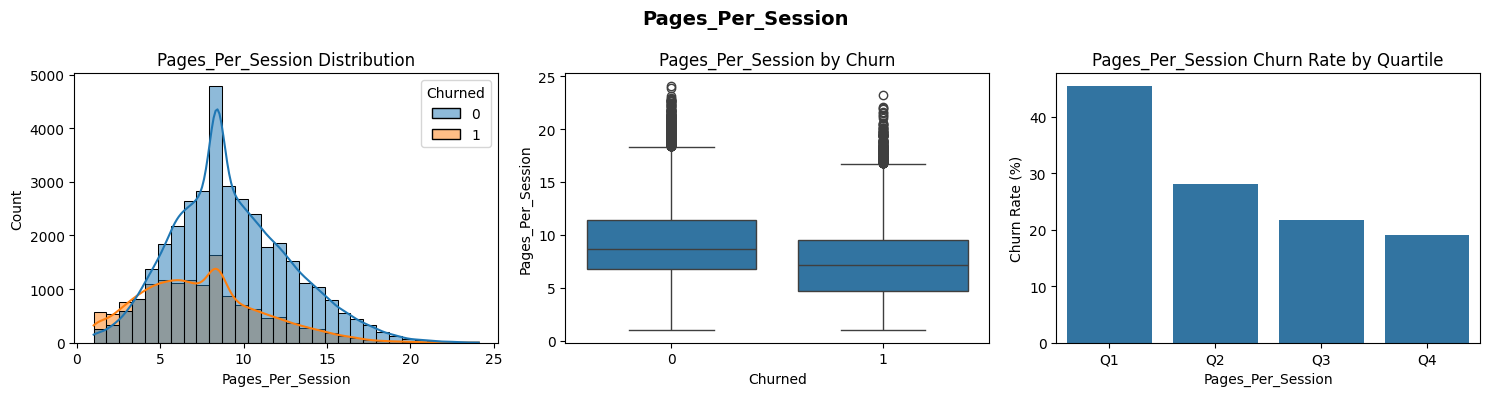

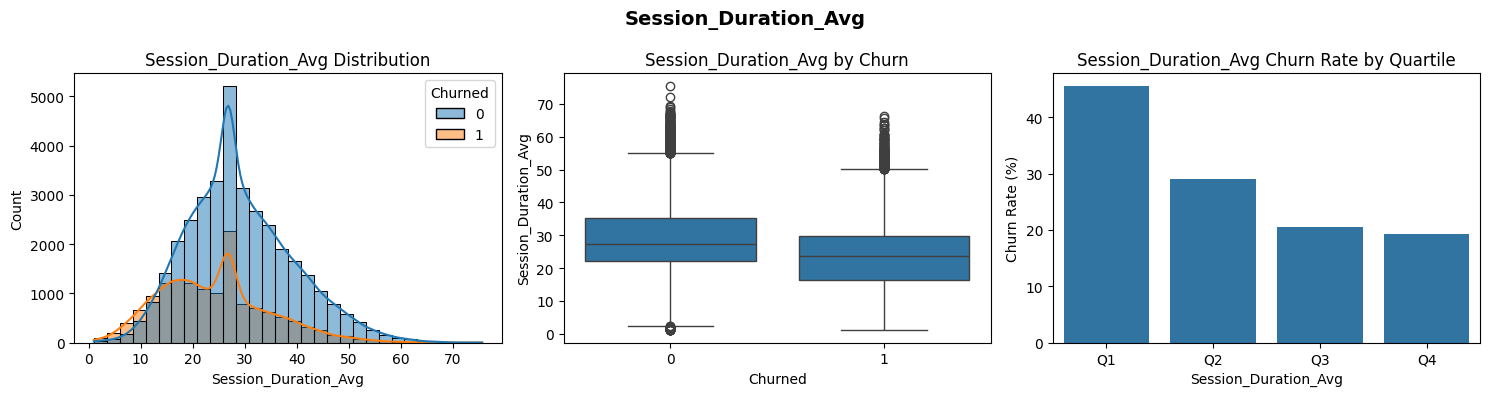

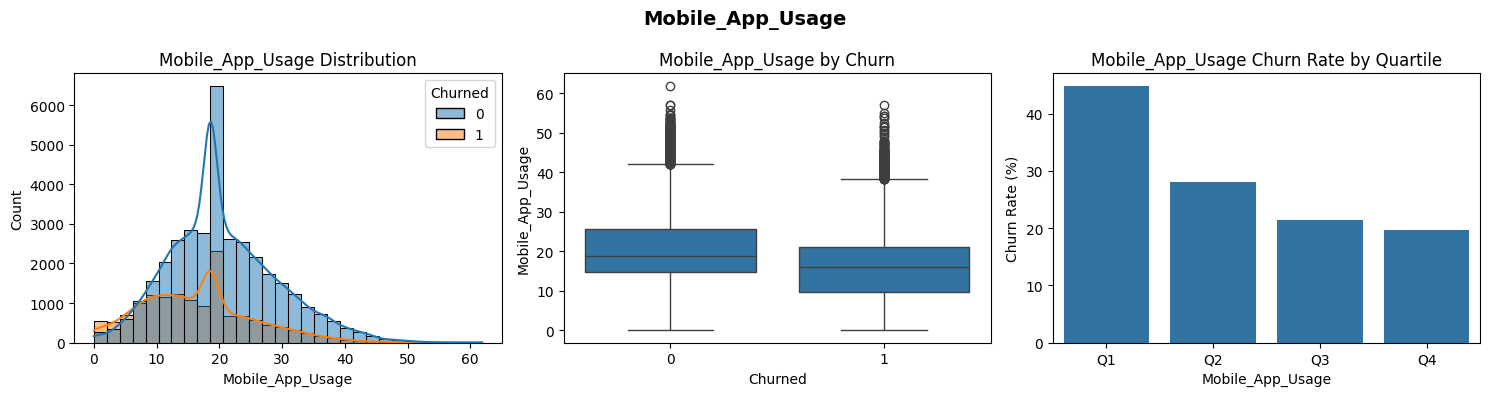

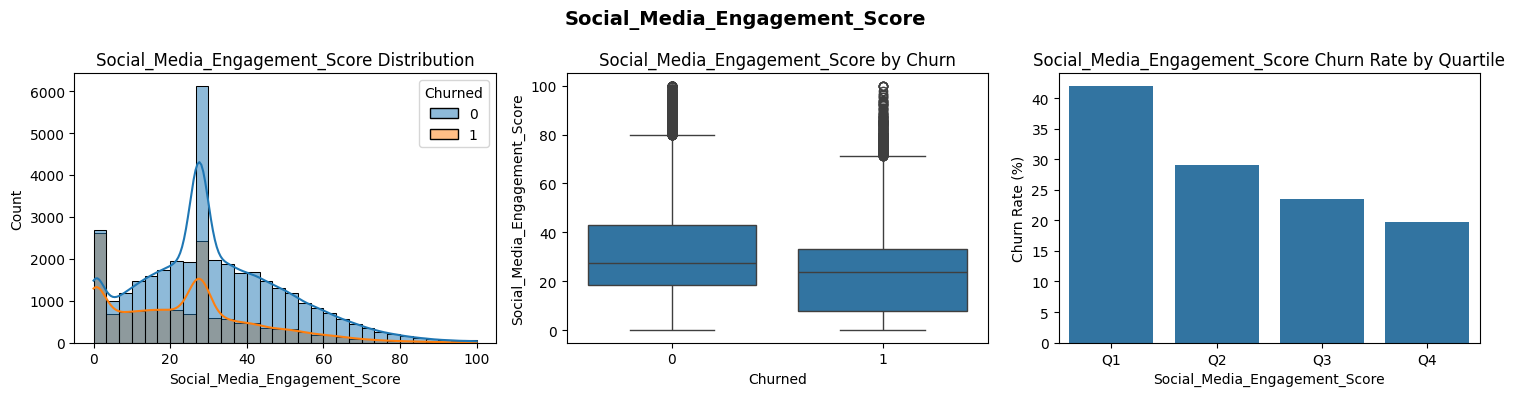

In [11]:
def analyze_feature(feature, df):
    """Analyze one engagement feature in 3 views: distribution, churn gap, and churn trend."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    sns.histplot(data=df, x=feature, hue='Churned', bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f'{feature} Distribution')
    
    sns.boxplot(data=df, x='Churned', y=feature, ax=axes[1])
    axes[1].set_title(f'{feature} by Churn')
    
    segments = pd.qcut(df[feature], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
    churn_rate = df.groupby(segments, observed=True)['Churned'].mean() * 100
    sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=axes[2])
    axes[2].set_title(f'{feature} Churn Rate by Quartile')
    axes[2].set_ylabel('Churn Rate (%)')
    
    plt.suptitle(feature, fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

for feature in engagement_feature_names:
    analyze_feature(feature, df)

In [12]:
summary_stats = engagement_data.describe().T
summary_stats['skewness'] = engagement_data.skew()
summary_stats['kurtosis'] = engagement_data.kurt()
summary_stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Login_Frequency,50000.0,11.624660,7.810657,0.0,6.0,11.0,17.0,46.0,0.511945,-0.144381
Pages_Per_Session,50000.0,8.717542,3.663996,1.0,6.2,8.4,11.0,24.1,0.419215,0.074851
Session_Duration_Avg,50000.0,27.602240,10.497234,1.0,20.2,26.8,34.0,75.6,0.431393,0.133731
Mobile_App_Usage,50000.0,19.294446,8.938875,0.0,13.2,18.6,24.6,61.9,0.452248,0.239742
Social_Media_Engagement_Score,50000.0,29.152730,19.308632,0.0,15.3,27.6,40.7,100.0,0.570295,0.150854


In [13]:
def rank_biserial_from_u(u_stat, n_churn, n_non_churn):
    auc_probability = u_stat / (n_churn * n_non_churn)
    return 2 * auc_probability - 1

def effect_label(value):
    abs_value = abs(value)
    if abs_value >= 0.5:
        return 'Large'
    if abs_value >= 0.3:
        return 'Medium'
    if abs_value >= 0.1:
        return 'Small'
    return 'Negligible'

rows = []
quartile_tables = {}

for feature in engagement_feature_names:
    churn = df.loc[df['Churned'] == 1, feature].dropna()
    non_churn = df.loc[df['Churned'] == 0, feature].dropna()

    u_stat, p_value = stats.mannwhitneyu(churn, non_churn, alternative='two-sided')
    rb = rank_biserial_from_u(u_stat, len(churn), len(non_churn))

    bins = pd.qcut(df[feature], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
    quartile_df = pd.DataFrame({'quartile': bins, 'Churned': df['Churned']})
    quartile_rate = quartile_df.groupby('quartile', observed=True)['Churned'].mean() * 100
    quartile_tables[feature] = quartile_rate

    rows.append({
        'feature': feature,
        'corr_with_churn': df[feature].corr(df['Churned']),
        'u_stat': u_stat,
        'p_value': p_value,
        'rank_biserial': rb,
        'effect_size_label': effect_label(rb),
        'churn_q1_pct': quartile_rate.iloc[0],
        'churn_q4_pct': quartile_rate.iloc[-1],
        'q4_minus_q1_pct': quartile_rate.iloc[-1] - quartile_rate.iloc[0],
    })

engagement_summary = pd.DataFrame(rows).sort_values('q4_minus_q1_pct', ascending=False).reset_index(drop=True)
engagement_summary

,feature,corr_with_churn,u_stat,p_value,rank_biserial,effect_size_label,churn_q1_pct,churn_q4_pct,q4_minus_q1_pct
0,Social_Media_Engagement_Score,-0.179829,196189396.5,0.0,-0.236168,Small,41.976392,19.743590,-22.232802
1,Login_Frequency,-0.204379,187085024.5,0.0,-0.271614,Small,43.457425,19.233846,-24.223579
2,Mobile_App_Usage,-0.211376,186822763.5,0.0,-0.272635,Small,44.802215,19.687324,-25.114891
3,Session_Duration_Avg,-0.219512,184940334.5,0.0,-0.279964,Small,45.506784,19.260388,-26.246395
4,Pages_Per_Session,-0.224708,182327891.5,0.0,-0.290135,Small,45.375232,18.990031,-26.385201


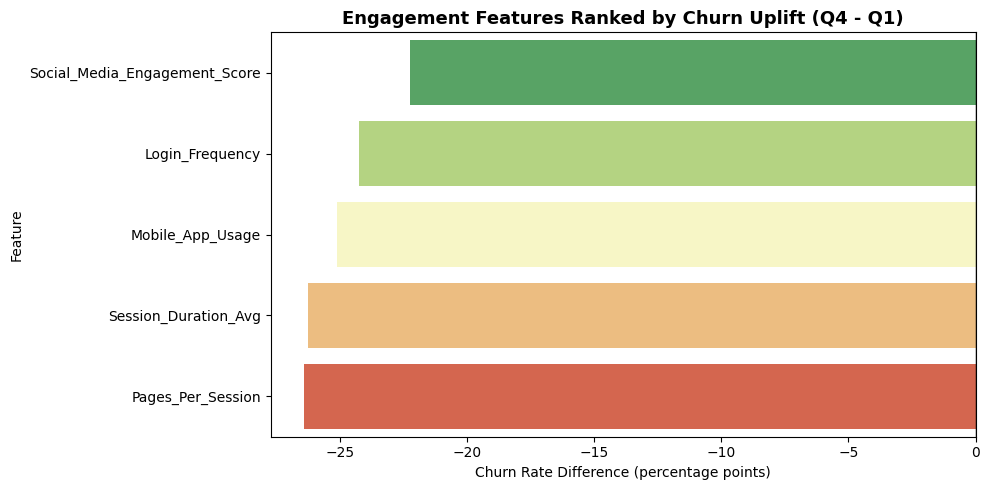

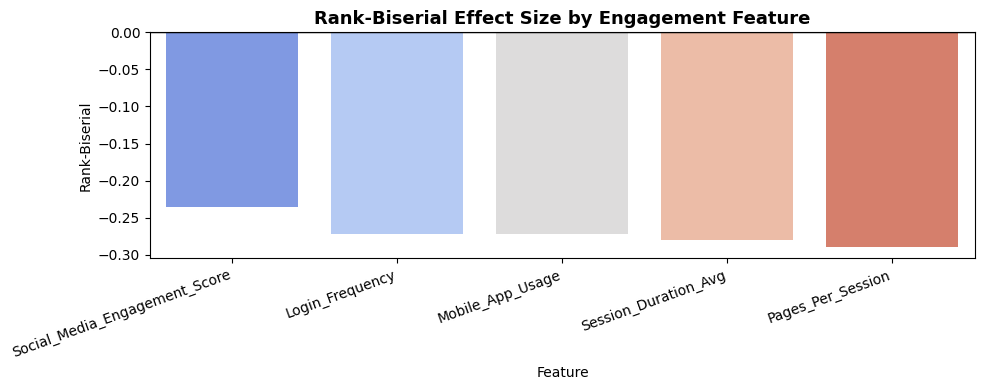

In [15]:
plot_df = engagement_summary.copy()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x='q4_minus_q1_pct',
    y='feature',
    hue='feature',
    palette='RdYlGn_r',
    legend=False
)
plt.axvline(0, color='black', linewidth=1)
plt.title('Engagement Features Ranked by Churn Uplift (Q4 - Q1)', fontsize=13, weight='bold')
plt.xlabel('Churn Rate Difference (percentage points)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
effect_df = plot_df.sort_values('rank_biserial', ascending=False)
sns.barplot(
    data=effect_df,
    x='feature',
    y='rank_biserial',
    hue='feature',
    palette='coolwarm',
    legend=False
)
plt.axhline(0, color='black', linewidth=1)
plt.title('Rank-Biserial Effect Size by Engagement Feature', fontsize=13, weight='bold')
plt.xlabel('Feature')
plt.ylabel('Rank-Biserial')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [14]:
display_cols = [
    'feature', 'corr_with_churn', 'p_value', 'rank_biserial',
    'effect_size_label', 'churn_q1_pct', 'churn_q4_pct', 'q4_minus_q1_pct'
]

display_df = engagement_summary.copy()
display_df['corr_with_churn'] = display_df['corr_with_churn'].round(3)
display_df['p_value'] = display_df['p_value'].map(lambda x: f'{x:.3e}')
display_df['rank_biserial'] = display_df['rank_biserial'].round(3)
display_df['churn_q1_pct'] = display_df['churn_q1_pct'].round(2)
display_df['churn_q4_pct'] = display_df['churn_q4_pct'].round(2)
display_df['q4_minus_q1_pct'] = display_df['q4_minus_q1_pct'].round(2)
display_df[display_cols]

,feature,corr_with_churn,p_value,rank_biserial,effect_size_label,churn_q1_pct,churn_q4_pct,q4_minus_q1_pct
0,Social_Media_Engagement_Score,-0.180,0.000e+00,-0.236,Small,41.98,19.74,-22.23
1,Login_Frequency,-0.204,0.000e+00,-0.272,Small,43.46,19.23,-24.22
2,Mobile_App_Usage,-0.211,0.000e+00,-0.273,Small,44.80,19.69,-25.11
3,Session_Duration_Avg,-0.220,0.000e+00,-0.280,Small,45.51,19.26,-26.25
4,Pages_Per_Session,-0.225,0.000e+00,-0.290,Small,45.38,18.99,-26.39


In [16]:
print('Executive Insight: Engagement Behavior vs Churn')
print('--------------------------------------------------')
for _, row in engagement_summary.iterrows():
    direction = 'higher' if row['q4_minus_q1_pct'] > 0 else 'lower'
    print(
        f"- {row['feature']}: Q4 churn is {abs(row['q4_minus_q1_pct']):.2f}pp {direction} than Q1, "
        f"effect={row['effect_size_label']} (rb={row['rank_biserial']:.3f}), p={row['p_value']:.2e}"
    )

engagement_summary.to_csv('../../../Data/processed/engagement_behavior_professional_summary.csv', index=False)
print('Saved: Data/processed/engagement_behavior_professional_summary.csv')

Executive Insight: Engagement Behavior vs Churn
--------------------------------------------------
- Social_Media_Engagement_Score: Q4 churn is 22.23pp lower than Q1, effect=Small (rb=-0.236), p=0.00e+00
- Login_Frequency: Q4 churn is 24.22pp lower than Q1, effect=Small (rb=-0.272), p=0.00e+00
- Mobile_App_Usage: Q4 churn is 25.11pp lower than Q1, effect=Small (rb=-0.273), p=0.00e+00
- Session_Duration_Avg: Q4 churn is 26.25pp lower than Q1, effect=Small (rb=-0.280), p=0.00e+00
- Pages_Per_Session: Q4 churn is 26.39pp lower than Q1, effect=Small (rb=-0.290), p=0.00e+00
Saved: Data/processed/engagement_behavior_professional_summary.csv
